# Function 2: Part 2 analysis notebook

This notebook keeps the original data-loading cells, appends the latest query point/output from the end of your uploaded notebook, and then runs one focused analysis for Part 2.

Assumption: lower output is better, so the optimisation target is minimisation.


In [ ]:
import numpy as np

input_data = np.load('../../data/initial_data/function_2/initial_inputs.npy')
print("Before:", input_data.shape)
new_point = np.array([
    [0.759048, 0.965375],
    [0.714910, 0.858164],
    [0.5, 0.5],
    ])
input_data = np.vstack([input_data, new_point])
print("After:", input_data.shape)
print(input_data)


Before: (10, 2)
After: (12, 2)
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.759048   0.965375  ]
 [0.71491    0.858164  ]]


In [ ]:
output_data = np.load('../../data/initial_data/function_2/initial_outputs.npy')
print("Before:", output_data.shape)
new_output = np.array([
    0.29645067004988124,
    0.4598605438093154,
    0.7881941889678203
    ])
output_data = np.append(output_data, new_output)
print("After:", output_data.shape)
print(output_data)


Before: (10,)
After: (12,)
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.29645067  0.45986054]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Latest query/output extracted from the uploaded notebook.
# Edit these if you later receive a different portal output.
latest_query = np.array([[0.5, 0.5]])
actual_output = 0.7881941889678203

# Append the latest query/output only if it is not already present.
if actual_output is not None:
    already_present = np.any(np.all(np.isclose(input_data, latest_query, atol=1e-12), axis=1))
    if not already_present:
        input_data = np.vstack([input_data, latest_query])
        output_data = np.append(output_data, actual_output)

function_id = 2
d = input_data.shape[1]
print(f"Function {function_id}, dimension d={d}")
print("Data shape:", input_data.shape, output_data.shape)
print("Current best observed y:", output_data.min())
print("Current best x:", input_data[np.argmin(output_data)])


Function 2, dimension d=2
Data shape: (13, 2) (13,)
Current best observed y: -0.06562362443733738
Current best x: [0.14269907 0.34900513]


In [5]:
# Basic table used in all interpretations
summary = pd.DataFrame(input_data, columns=[f"x{i+1}" for i in range(d)])
summary["y"] = output_data
summary["log_abs_y"] = np.log(np.abs(output_data) + 1e-300)
summary["rank_min"] = summary["y"].rank(method="first", ascending=True).astype(int)
summary = summary.sort_values("y")
display(summary)


,x1,x2,y,log_abs_y,rank_min
2,0.142699,0.349005,-0.065624,-2.723820,1
8,0.338648,0.213867,-0.013858,-4.278920,2
5,0.577713,0.771973,0.023106,-3.767682,3
7,0.341750,0.028698,0.038749,-3.250650,4
4,0.454647,0.290455,0.214965,-1.537282,5
6,0.438166,0.685018,0.244619,-1.408052,6
3,0.845275,0.711120,0.293993,-1.224200,7
10,0.759048,0.965375,0.296451,-1.215874,8
1,0.877791,0.778628,0.420586,-0.866106,9
11,0.714910,0.858164,0.459861,-0.776832,10


## Gaussian process surrogate + expected improvement for minimisation

In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

# Standardise inputs and outputs for numerical stability.
X = input_data.copy()
y = output_data.copy()

x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d), length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))

gp = GaussianProcessRegressor(kernel=kernel, normalize_y=False, n_restarts_optimizer=20, random_state=0)
gp.fit(X_scaled, y_scaled)

print("Fitted kernel:", gp.kernel_)
print("Best observed y:", y.min())
print("Best observed x:", X[np.argmin(y)])


Fitted kernel: 1**2 * Matern(length_scale=[0.133, 100], nu=2.5) + WhiteKernel(noise_level=0.0104)
Best observed y: -0.06562362443733738
Best observed x: [0.14269907 0.34900513]


/Users/andriy/miniconda3/envs/appenv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [7]:
def expected_improvement_min(X_candidates, gp, y_best_scaled, xi=0.01):
    """Expected improvement for minimisation in scaled y-space."""
    mu, sigma = gp.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-12)
    improvement = y_best_scaled - mu - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# Random candidate search in [0, 1]^d. Increase n_candidates for a more exhaustive search.
rng = np.random.default_rng(0)
n_candidates = 20000 if d <= 4 else 50000
candidates = rng.random((n_candidates, d))
candidates_scaled = x_scaler.transform(candidates)

y_best_scaled = y_scaled.min()
ei = expected_improvement_min(candidates_scaled, gp, y_best_scaled, xi=0.01)
mu_scaled, std_scaled = gp.predict(candidates_scaled, return_std=True)
mu = y_scaler.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()
std = std_scaled * y_scaler.scale_[0]

results = pd.DataFrame(candidates, columns=[f"x{i+1}" for i in range(d)])
results["pred_mean"] = mu
results["pred_std"] = std
results["expected_improvement"] = ei
results = results.sort_values("expected_improvement", ascending=False)

display(results.head(10))

best_next = results.iloc[0][[f"x{i+1}" for i in range(d)]].to_numpy(dtype=float)
print("Suggested next query:", np.round(best_next, 6))
print("Portal format:", ", ".join(f"x{i+1}={v:.6f}" for i, v in enumerate(best_next)))


,x1,x2,pred_mean,pred_std,expected_improvement
3746,0.319038,0.842697,0.016818,0.167245,0.130115
8772,0.319131,0.951911,0.016217,0.166719,0.130114
7417,0.318945,0.777489,0.017424,0.167771,0.130113
2008,0.318746,0.997649,0.018775,0.168942,0.130108
6609,0.319151,0.772059,0.016069,0.166583,0.130103
18139,0.319252,0.827136,0.015407,0.165997,0.130092
3508,0.318837,0.514571,0.018136,0.168376,0.130092
18682,0.319370,0.836465,0.014639,0.165309,0.130069
19365,0.319103,0.256287,0.016407,0.166854,0.130069
17723,0.319374,0.771937,0.014611,0.165281,0.130065


Suggested next query: [0.319038 0.842697]
Portal format: x1=0.319038, x2=0.842697


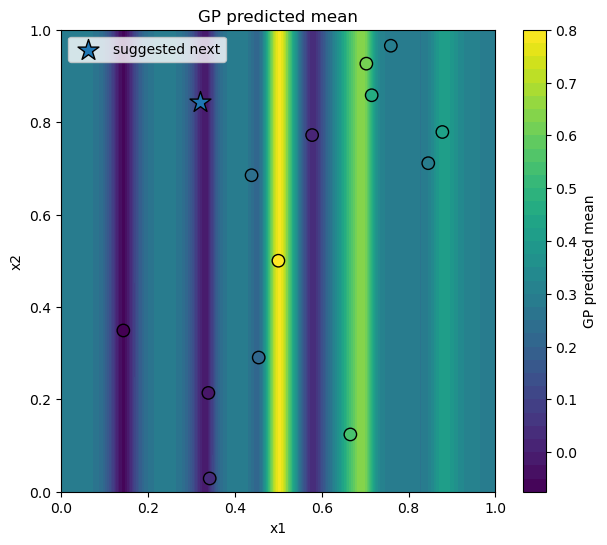

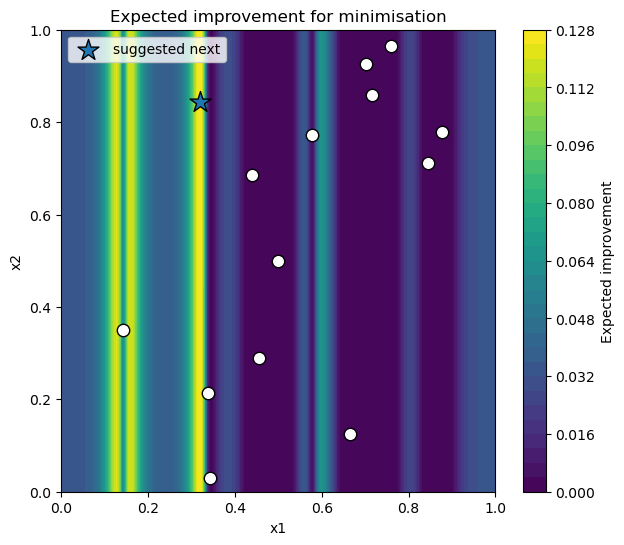

In [8]:
# Optional 2D visualisation only when d=2
if d == 2:
    grid_res = 150
    xx, yy = np.meshgrid(np.linspace(0, 1, grid_res), np.linspace(0, 1, grid_res))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = x_scaler.transform(grid)
    mu_grid_scaled, std_grid_scaled = gp.predict(grid_scaled, return_std=True)
    mu_grid = y_scaler.inverse_transform(mu_grid_scaled.reshape(-1, 1)).reshape(grid_res, grid_res)
    ei_grid = expected_improvement_min(grid_scaled, gp, y_best_scaled).reshape(grid_res, grid_res)

    plt.figure(figsize=(7, 6))
    cf = plt.contourf(xx, yy, mu_grid, levels=40)
    plt.colorbar(cf, label="GP predicted mean")
    plt.scatter(input_data[:, 0], input_data[:, 1], c=output_data, edgecolors="black", s=80)
    plt.scatter(best_next[0], best_next[1], marker="*", s=250, edgecolors="black", label="suggested next")
    plt.xlabel("x1"); plt.ylabel("x2"); plt.title("GP predicted mean")
    plt.legend(); plt.show()

    plt.figure(figsize=(7, 6))
    cf = plt.contourf(xx, yy, ei_grid, levels=40)
    plt.colorbar(cf, label="Expected improvement")
    plt.scatter(input_data[:, 0], input_data[:, 1], c="white", edgecolors="black", s=80)
    plt.scatter(best_next[0], best_next[1], marker="*", s=250, edgecolors="black", label="suggested next")
    plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Expected improvement for minimisation")
    plt.legend(); plt.show()
